# Week 7 — Day 1 Sprint 2 Planning & Convolutional Neural Networks
### Dataset
Melanoma Skin Cancer Dataset — Benign vs Malignant

### Main Goal
Understand why Convolutional Neural Networks (CNNs) are suitable for image
classification and apply a hand-defined convolution filter to a sample image.

### Learning Objectives
- Complete Sprint 2 planning and define the core-model backlog.
- Explain why dense networks are inefficient for images.
- Understand convolution, filters, feature maps, stride, and padding.
- Explain parameter sharing and translation invariance.
- Understand the feature hierarchy learned by CNNs.
- Select the appropriate neural network architecture for the project.

#  Sprint 2 Planning

## Sprint Goal

The goal of Sprint 2 is to develop the project's core deep learning model
using an architecture suitable for image classification.

Since the project uses skin lesion images, a Convolutional Neural Network
(CNN) will be used as the core model architecture.

## Sprint 2 Backlog

1. Prepare the melanoma image dataset for CNN training.
2. Define the image input size and preprocessing pipeline.
3. Build a CNN-based core model.
4. Train the CNN model using training and validation data.
5. Evaluate the model using appropriate classification metrics.
6. Compare the CNN performance with the previous baseline.
7. Track experiments and their configurations systematically.
8. Compare validation and final evaluation results across experiments.
9. Save the best-performing model.
10. Document the model architecture, experiments, and results.

## Sprint 1 Retrospective

### What Went Well?

* Built and trained a complete neural network using Keras.
* Used validation data to guide model tuning.
* Tested the main high-impact hyperparameters systematically.
* Added EarlyStopping and ModelCheckpoint.
* Documented model performance and compared it with the baseline.

### What Could Be Improved?

* Experiment configurations and results could be tracked more systematically.
* Future experiments could be organized in a dedicated experiment log.
* Hyperparameter interactions could be investigated after the one-variable-at-a-time tuning stage.

### One Concrete Change for Sprint 2

For Sprint 2, every experiment will be recorded with its configuration,
validation result, and final evaluation so that model changes can be compared
more clearly.

## Sprint 2 Process Improvement

An experiment log will be maintained throughout Sprint 2.

Each experiment will record:

* Experiment ID
* Model configuration
* Hyperparameters
* Validation result
* Final evaluation result
* Notes and observations

This will make model comparisons more systematic and reproducible.


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

##  Project Data Type

The project uses image data.

Each sample is a skin lesion image and the target classification is:

- Benign
- Malignant

Therefore, this is an image classification problem.

Because images contain spatial relationships between neighboring pixels,
the model should preserve this spatial structure instead of treating every
pixel as an independent feature.

#  Why Dense Networks Fail on Images

A dense neural network is not the most suitable architecture for image data.

For example, consider a 200 × 200 RGB image:

200 × 200 × 3 = 120,000 pixel values

If these values are flattened and connected to a dense layer containing
128 neurons:

120,000 × 128 = 15,360,000 weights

This creates a very large number of parameters.

More importantly, flattening the image removes the spatial structure.
Nearby pixels that form meaningful patterns such as edges, curves, and
textures are no longer treated as spatially connected.

CNNs solve this problem by using small filters that move across the image
and detect local patterns.

### Calculating the number of parameters

In [4]:
image_height = 200
image_width = 200
channels = 3
dense_neurons = 128
input_values = image_height * image_width * channels
dense_weights = input_values * dense_neurons

print("Number of input values:", input_values)
print("Dense layer neurons:", dense_neurons)
print("Dense layer weights:", dense_weights)

Number of input values: 120000
Dense layer neurons: 128
Dense layer weights: 15360000


## Why is this inefficient?

A dense network connects every input value to every neuron in the next layer.

For an image, this leads to a very large number of parameters and ignores
the local spatial relationships between neighboring pixels.

A CNN instead uses small filters that are reused across different locations
of the image.

This makes CNNs much more parameter-efficient for image data.

#  Convolution — Core Idea

Convolution is the main operation used by CNNs.

A small filter, also called a kernel, slides across the image.

At each position, the values of the filter are multiplied by the
corresponding image values and then summed.

The resulting values form a feature map.

Conceptually:

Image-->Small Filter-->Local Dot Products-->Feature Map
The filter can learn to detect patterns such as edges, curves, textures,
and other visual features.

#  Main Convolution Concepts
| Concept | Meaning |
|---|---|
| Filter / Kernel | Small learnable grid of weights used to detect a pattern |
| Feature Map | Output showing where the detected pattern appears |
| Stride | Number of pixels the filter moves at each step |
| Padding | Extra border added around the image |

#  Load a Sample Image

In this section, we will load one image from the melanoma dataset and use
it to demonstrate convolution manually.

The purpose of this experiment is to understand convolution.

It is not the final CNN model.

In [5]:
from google.colab import files

uploaded = files.upload()

print("Uploaded files:")
for filename in uploaded.keys():
    print(filename)

Saving archive (9).zip to archive (9).zip
Uploaded files:
archive (9).zip


#### Decompression

In [6]:
import zipfile
import os

zip_files = [f for f in uploaded.keys() if f.lower().endswith(".zip")]

if len(zip_files) == 0:
    print("No ZIP file found.")
else:
    zip_path = zip_files[0]
    extract_path = "/content/melanoma_dataset"

    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extract_path)

    print("Dataset extracted to:")
    print(extract_path)

Dataset extracted to:
/content/melanoma_dataset


#### Data Exploration

In [7]:
for root, dirs, files_list in os.walk("/content/melanoma_dataset"):
    level = root.replace("/content/melanoma_dataset", "").count(os.sep)
    indent = "  " * level

    print(f"{indent}{os.path.basename(root)}/")

    for file in files_list[:5]:
        print(f"{indent}  {file}")

    if level >= 2:
        dirs[:] = []

melanoma_dataset/
  test/
    Malignant/
      5658.jpg
      5969.jpg
      6196.jpg
      6298.jpg
      5884.jpg
    Benign/
      6923.jpg
      7256.jpg
      6781.jpg
      6546.jpg
      6372.jpg
  train/
    Malignant/
      3938.jpg
      1136.jpg
      2498.jpg
      3657.jpg
      4104.jpg
    Benign/
      3938.jpg
      5658.jpg
      1136.jpg
      2498.jpg
      3657.jpg


#### Automatically search for images

In [8]:
image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

image_paths = []

for root, dirs, files_list in os.walk("/content/melanoma_dataset"):
    for file in files_list:
        if file.lower().endswith(image_extensions):
            image_paths.append(os.path.join(root, file))

print("Total images found:", len(image_paths))

print("\nFirst 10 image paths:")
for path in image_paths[:10]:
    print(path)

Total images found: 13879

First 10 image paths:
/content/melanoma_dataset/test/Malignant/5658.jpg
/content/melanoma_dataset/test/Malignant/5969.jpg
/content/melanoma_dataset/test/Malignant/6196.jpg
/content/melanoma_dataset/test/Malignant/6298.jpg
/content/melanoma_dataset/test/Malignant/5884.jpg
/content/melanoma_dataset/test/Malignant/5867.jpg
/content/melanoma_dataset/test/Malignant/6546.jpg
/content/melanoma_dataset/test/Malignant/6372.jpg
/content/melanoma_dataset/test/Malignant/6194.jpg
/content/melanoma_dataset/test/Malignant/5920.jpg


#### View Sample Image

Image path: /content/melanoma_dataset/test/Malignant/5658.jpg
Image size: (224, 224)
Image mode: RGB


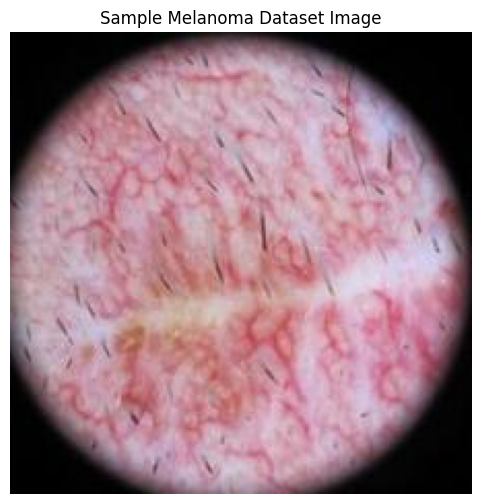

In [9]:
sample_path = image_paths[0]

image = Image.open(sample_path)

print("Image path:", sample_path)
print("Image size:", image.size)
print("Image mode:", image.mode)

plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis("off")
plt.title("Sample Melanoma Dataset Image")
plt.show()

## Observation

The sample image is a color skin lesion image.
Images contain spatial information because neighboring pixels are related.
For example, edges and textures are created by groups of nearby pixels.
This spatial structure is one of the main reasons CNNs are suitable for
this project.

## Convert the image to grayscale.

In [11]:
image_gray = image.convert("L")
image_gray_array = np.array(image_gray)
print("Original image shape:", np.array(image).shape)
print("Grayscale image shape:", image_gray_array.shape)

Original image shape: (224, 224, 3)
Grayscale image shape: (224, 224)


### Grayscale Display

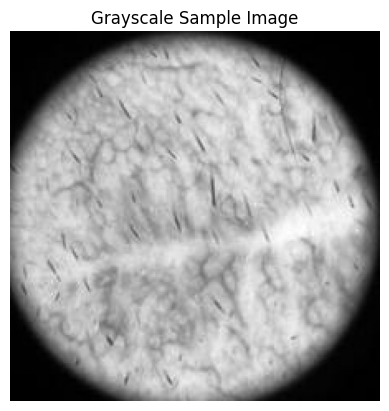

In [17]:
plt.imshow(image_gray_array, cmap="gray")
plt.axis("off")
plt.title("Grayscale Sample Image")
plt.show()

#  Hand-Defined Edge Detection Filter
To understand convolution, we will define a simple edge-detection filter
manually.
The filter is:
[-1  0  1]
[-1  0  1]
[-1  0  1]
This filter responds strongly to vertical changes in intensity.
In a real CNN, filters are not manually designed. They are learned from
the training data.

In [14]:
edge_filter = np.array([[-1, 0, 1],[-1, 0, 1],[-1, 0, 1]])
print(edge_filter)

[[-1  0  1]
 [-1  0  1]
 [-1  0  1]]


## Apply Convolution

In [15]:

from scipy.signal import convolve2d

feature_map = convolve2d(
    image_gray_array,
    edge_filter,
    mode="same",
    boundary="symm"
)

print("Original image shape:", image_gray_array.shape)
print("Feature map shape:", feature_map.shape)

Original image shape: (224, 224)
Feature map shape: (224, 224)


### Displaying the image and the feature map.

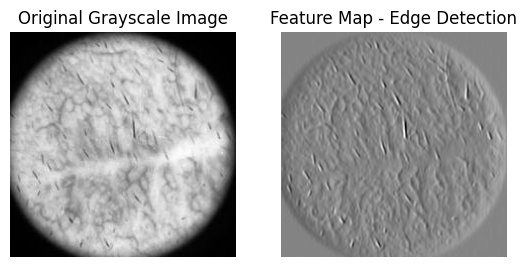

In [18]:
plt.subplot(1, 2, 1)
plt.imshow(image_gray_array, cmap="gray")
plt.title("Original Grayscale Image")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(feature_map, cmap="gray")
plt.title("Feature Map - Edge Detection")
plt.axis("off")
plt.show()

### Interpretation

The hand-defined filter was applied across the entire image.

The resulting feature map highlights areas where the image contains
strong vertical changes in pixel intensity.

This demonstrates the basic idea of convolution:

- A small filter is applied locally.
- The filter moves across the image.
- A numerical response is produced at each position.
- These responses form a feature map.

In a CNN, the filters are learned automatically during training instead
of being manually defined.

#  Stride
Stride determines how far the filter moves after each convolution step.
### Stride = 1
The filter moves one pixel at a time.
### Stride = 2
The filter moves two pixels at a time.
A larger stride usually produces a smaller output feature map.
In this experiment, the convolution operation uses a small movement across
the image to demonstrate how local features can be detected.

# Padding
Padding means adding extra pixels around the border of an image before
performing convolution.
Padding is useful because:
1. It allows filters to process border pixels.
2. It can help preserve spatial dimensions.
3. It gives the network more information from image boundaries.
Common padding options include:
- VALID: no padding.
- SAME: padding is used so that the output can preserve the spatial size
  when stride = 1.

#  Parameter Sharing
One of the biggest advantages of CNNs is parameter sharing.
A CNN uses the same filter across different locations of an image.
For example, a 3 × 3 grayscale filter contains:
3 × 3 = 9 weights
These same weights are reused across the entire image.
In contrast, a dense layer connects every input pixel to every neuron.
Therefore, CNNs require far fewer parameters while still being able to
detect the same pattern in different locations.

In [19]:
filter_size = 3
cnn_filter_weights = filter_size * filter_size
print("3x3 CNN filter weights:", cnn_filter_weights)
print("Dense example weights:", dense_weights)
print("Dense / CNN weight ratio:", round(dense_weights / cnn_filter_weights, 2))

3x3 CNN filter weights: 9
Dense example weights: 15360000
Dense / CNN weight ratio: 1706666.67


# Translation Invariance
A CNN applies the same filter across the entire image.
Therefore, a learned pattern can be detected even when it appears in
different locations.
For example, if a filter learns to detect a particular edge, it can detect
that edge near the top, middle, or bottom of the image.
This ability to detect patterns across different spatial locations makes
CNNs highly suitable for image data.

#  Feature Hierarchy
CNNs learn visual features in a hierarchy.
### Early Layers
Learn simple features such as:
- Edges
- Lines
- Simple curves
### Middle Layers
Combine simple features into:
- Shapes
- Textures
- More complex patterns
### Deeper Layers
Learn more complex representations that can help distinguish between
different image classes.
For this project, the general idea is:
Pixels-->Edges-->Textures and Shapes-->Complex Lesion Patterns-->Benign / Malignant
The features are learned automatically from the training data.

# Architecture Decision

| Data Type | Suitable Architecture |
|---|---|
| Images | CNN |
| Text / Sequential Data | RNN / Transformer |
| Tabular Data | Dense Neural Network |

### Project Decision

The project's data consists of skin lesion images.

Therefore:

**Selected Architecture: CNN**

### Reason

CNNs are designed to process spatial image information and learn local
visual patterns such as edges, textures, and shapes.

A dense network would require flattening the image and would lose much of
the spatial structure.

### A simple verification using TensorFlow/Keras

In [20]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

conv_layer = tf.keras.layers.Conv2D(
    filters=1,
    kernel_size=(3, 3),
    strides=(1, 1),
    padding="same"
)

print(conv_layer)

TensorFlow version: 2.20.0
<Conv2D name=conv2d, built=False>


### What does this layer represent?

- filters = 1 → one feature detector
- kernel_size = 3 × 3 → a small local window
- strides = 1 × 1 → move one pixel at a time
- padding = same → preserve the spatial dimensions when stride = 1

The actual filter weights in a CNN are learned during training.

# Hands-On Lab: Building and Transferring a CNN

### Task 1 — Build and train a small CNN from scratch on an image dataset and record its accuracy

* Built and trained a small CNN from scratch using the melanoma skin cancer image dataset.
* Recorded the training and validation accuracy to establish a baseline CNN model.

### Task 2 — Add data augmentation and compare the new validation curves to the previous run.

* Added data augmentation to the CNN training pipeline.
* Trained the augmented CNN model.
* Compared the new validation curves with the previous CNN run to evaluate the effect of data augmentation.

### Task 3 — Apply transfer learning with a frozen pre-trained model (e.g. MobileNetV2) and compare accuracy and training time.

* Applied transfer learning using a frozen pre-trained MobileNetV2 model.
* Trained the classification head on the melanoma dataset.
* Compared the transfer learning model's accuracy and training time with the CNN trained from scratch.

### Task 4 —  Document which approach performed best and why, in Markdown

* Compared the performance of the CNN from scratch, the augmented CNN, and the MobileNetV2 transfer learning model.
* Documented the best-performing approach based on validation/test accuracy and training time.
* Explained why the selected approach performed better than the alternatives.